<a href="https://colab.research.google.com/github/hkumi/Be12pp-simulation/blob/main/Project_9_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing all the libraries

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
heart_dataset = pd.read_csv("/content/heart_disease_data.csv")

In [3]:
heart_dataset.shape

(303, 14)

In [4]:
heart_dataset.head(15)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [5]:
heart_dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
heart_dataset["target"].value_counts()

,count
target,
1,165
0,138


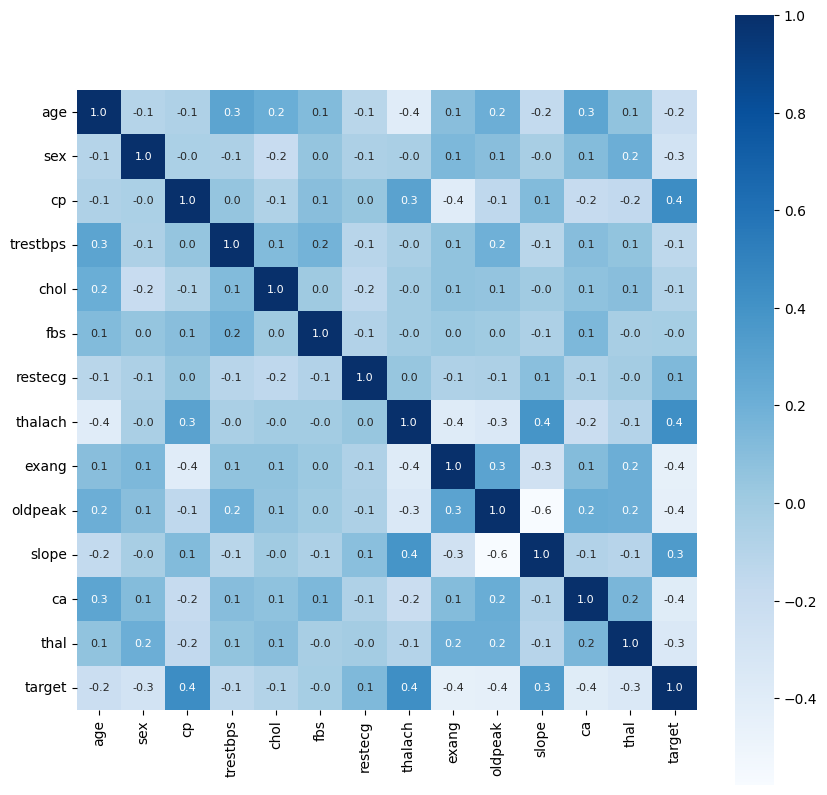

In [10]:
correlation = heart_dataset.corr()
# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size": 8}, cmap="Blues")
plt.show()

<Axes: xlabel='target', ylabel='Count'>

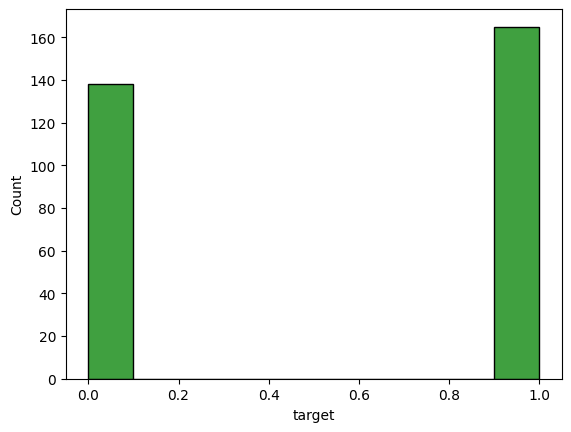

In [11]:
sns.histplot(heart_dataset['target'],color="green")

<Axes: xlabel='sex', ylabel='count'>

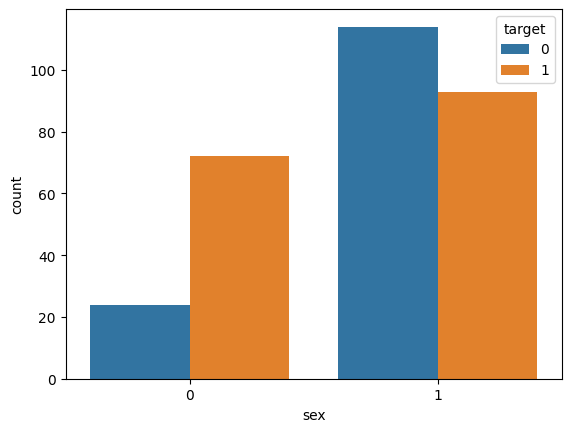

In [13]:

sns.countplot(x="sex",hue="target",data=heart_dataset) #Gender of the patient (0 = male, 1 = female)

<Axes: xlabel='cp', ylabel='count'>

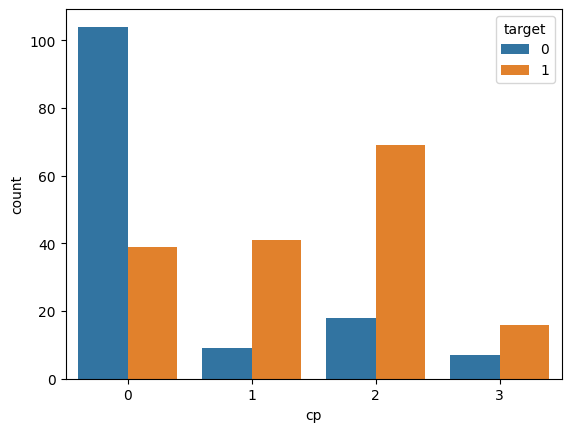

In [14]:
sns.countplot(x="cp",hue="target",data=heart_dataset) #Chest pain type:
#0: Typical angina
#1: Atypical angina
#2: Non-anginal pain
#3: Asymptomatic

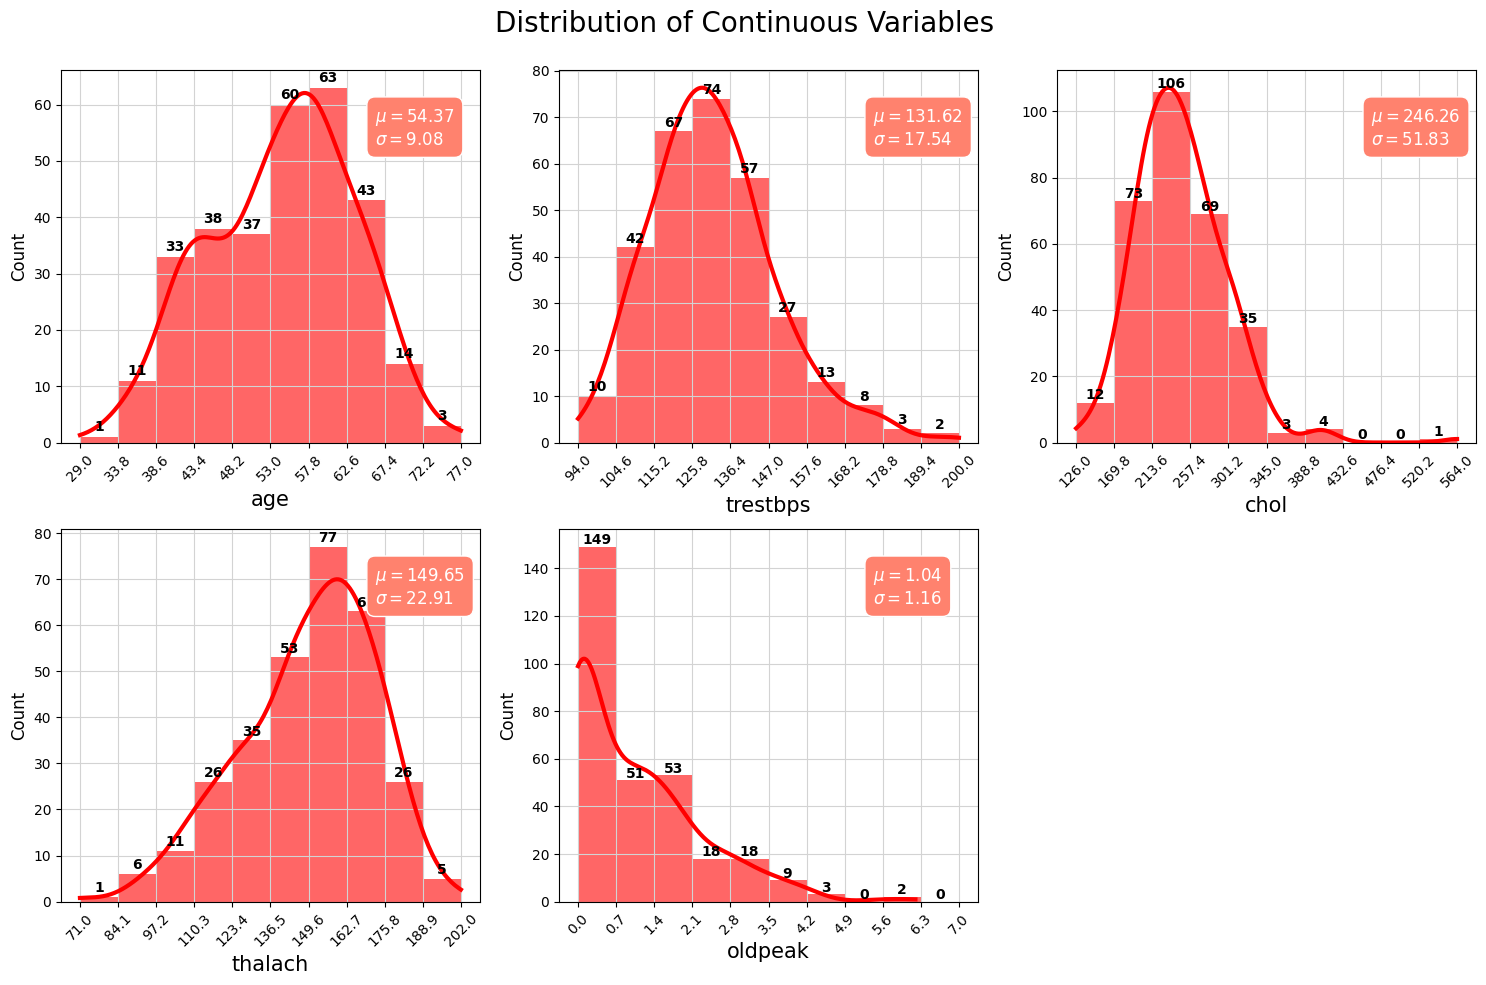

In [16]:
# Filter out continuous features for the univariate analysis
# Define the continuous features
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_continuous = heart_dataset[continuous_features]

# Set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(df_continuous[col],
                                     range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max())))

    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x, y],
                         edgecolor='none', color='red', alpha=0.6, line_kws={'lw': 3})
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')

    for j, p in enumerate(graph.patches):
        ax[x, y].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")

    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))
    ax[x, y].text(0.75, 0.9, textstr, transform=ax[x, y].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

ax[1,2].axis('off')
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [17]:
X = heart_dataset.drop(columns="target", axis = 1)
Y = heart_dataset["target"]

In [18]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [19]:
print(X_train.shape)

(242, 13)


In [20]:
classifier = svm.SVC(kernel="linear")

In [21]:
classifier.fit(X_train,Y_train)

SVC(kernel='linear')

In [22]:
#accuracy on the training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction,Y_train)

In [23]:
print(training_data_accuracy)

0.8553719008264463


In [24]:
#Accuracy on test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction,Y_test)

In [25]:
print(test_data_accuracy)

0.819672131147541


In [27]:
input_data =(62,	1,	0,	120,	267,	0,	1,	99,	1,	1.8,	1,	2,	3)

#changing the data type into numpy array

input_data_as_numpy_array = np.asarray(input_data)
#reshape the numpy array as we are predicting for one instance
input_data_reshape = input_data_as_numpy_array.reshape(1,-1)
prediction = classifier.predict(input_data_reshape)
if (prediction[0] == 0):
  print ("this patient doesnt have heart_disease")

else:
  print("this patient have heart_disease")

this patient doesnt have heart_disease


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
